<a href="https://colab.research.google.com/github/GoudoMahan/AI-agent-practice/blob/main/Homework01_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: RNN 序列到序列中英翻译 (Seq2Seq)

**【任务大背景】**
**机器翻译**：让计算机把一种语言的句子自动转换成另一种语言，例如中文→英文。这是自然语言处理（NLP）的核心任务之一。

本任务使用 **RNN（循环神经网络）**：一种能处理"序列"的神经网络，适合按顺序读入/生成文字。我们采用经典的 **Encoder-Decoder（编码器-解码器）架构**：
- **编码器（Encoder）**：像"读句子"，把整句中文依次读完后，压缩成一个固定长度的向量（称为**上下文向量**或 **hidden state**），表示这句话的含义。
- **解码器（Decoder）**：像"写句子"，从该向量出发，一个词一个词地生成英文翻译。

---

### 本 notebook 设计思路：「框架代码 + AI 填空」

| 类别 | 内容 | 由谁编写 |
|------|------|----------|
| **框架代码** | 全局配置、工具类 (Vocab/Dataset)、数据验证、模型实例化、训练调用、推理评估、可视化 | **已提供** ✅ |
| **AI 填空** | `load_and_preprocess_data()` / `build_model()` / `train_model()` 三个函数体 | **AI 生成** 🤖 |

**整体流程分为 3 个核心步骤（对应 3 个 AI 填写的函数）：**
1. **数据准备** `load_and_preprocess_data()` — 加载中英句对、分词、建词表、编码
2. **模型定义** `build_model()` — 定义 Encoder + Decoder + Seq2Seq 网络结构
3. **模型训练** `train_model()` — 使用 Teacher Forcing 训练模型

其余代码（环境配置、数据验证、模型实例化、推理评估、可视化等）已全部提供，只需顺序运行。

**函数调用关系：**
```
load_and_preprocess_data(file_path, num_pairs, train_ratio)
    → pairs, src_vocab, tgt_vocab, train_data, val_data
                    ↓
build_model(src_vocab_size, tgt_vocab_size, emb_dim, hid_dim, ...)
    → model (Seq2Seq)
                    ↓
train_model(model, train_loader, num_epochs, lr, vocab_size, pad_idx)
    → epoch_losses
                    ↓
translate_sentence(sentence, model, src_vocab, tgt_vocab, ...)  [已提供]
    → 英文翻译字符串
```

> **使用方式：** 将每个 Part 中「📋 复制给 AI 的提示词」发给 AI，让 AI 实现函数体，粘贴到对应的代码 cell 中运行。

> **📌 注意：** 所有图表（标题、坐标轴、图例）必须使用英文，防止中文乱码。

## Part 2.0: 环境准备与依赖安装（必做）

**【目的】**
先一次性安装 Task 2（RNN 中英翻译）需要的依赖，后续 Part 2.1~2.3 + 附加挑战直接复用环境。

**【说明】**
- 这个环节不需要 AI 生成代码，直接运行下方 cell 即可。
- 建议在 **Colab T4 GPU** 环境下执行。

**📖 概念解释**
- **依赖（dependency）**：本任务用到的库，如 PyTorch（深度学习框架）、jieba（中文分词）、nltk（含 BLEU 等工具）。安装一次后，同一环境里后续代码都可直接 `import` 使用。
- **GPU / cuda**：训练神经网络时大量矩阵运算，用 GPU 比 CPU 快很多。代码里把数据和模型放到 `device='cuda'`，即让它们在 GPU 上计算，可明显缩短训练时间。

In [ ]:
# @title
# ============================================================
# Part 2.0: 环境安装 + 数据下载（直接运行，无需 AI）
# ============================================================

# 安装深度学习框架 PyTorch
!pip -q install torch torchvision torchaudio

# 安装中文分词工具 jieba
!pip -q install jieba

# 安装自然语言处理工具包 nltk（用于 BLEU 评估）
!pip -q install nltk

# 安装可视化及数值计算库
!pip -q install matplotlib numpy

# 下载 Tatoeba 中英句对数据集（每行格式: 英文\t中文\t来源）
import os
if not os.path.exists('cmn-eng'):
    !wget -q https://www.manythings.org/anki/cmn-eng.zip
    !unzip -qo cmn-eng.zip -d cmn-eng
    print('数据集下载并解压完成。')
else:
    print('数据集已存在，跳过下载。')

print('Task 2 所有依赖安装完成。')

数据集下载并解压完成。
Task 2 所有依赖安装完成。


In [ ]:
# @title
# ============================================================
# 全局配置、工具类与辅助函数（直接运行，无需 AI）
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import jieba
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import os
import random

# 下载 nltk 数据（BLEU 计算所需）
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# -------------------- 超参数配置 --------------------
# 所有超参数集中管理，修改时只改这里即可
CONFIG = {
    'file_path': 'cmn-eng/cmn.txt',    # 数据文件路径
    'num_pairs': 20000,                  # 使用的句对数量
    'batch_size': 64,                    # 每个 batch 的样本数
    'train_ratio': 0.8,                  # 训练集比例（剩余为验证集）
    'embedding_dim': 256,                # 词嵌入维度
    'hidden_dim': 512,                   # GRU 隐藏层维度
    'num_layers': 1,                     # GRU 层数
    'num_epochs': 15,                    # 训练轮数
    'learning_rate': 1e-3,               # 学习率
    'max_len': 50,                       # 解码时最大生成长度
    'checkpoint_dir': './training_checkpoints',
    'checkpoint_path': './training_checkpoints/seq2seq.pt',
    'seed': 42,
}

# 设置随机种子，保证结果可复现
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

# 自动选择计算设备：有 GPU 用 GPU，否则用 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前计算设备: {device}")


# -------------------- 词表类 --------------------
class Vocab:
    """
    词表类：管理 词与索引 的双向映射。

    特殊标记（固定索引）:
        <PAD>=0  填充标记，让不等长的句子对齐成相同长度
        <SOS>=1  句子开始标记，告诉解码器"开始翻译"
        <EOS>=2  句子结束标记，告诉解码器"翻译结束"
        <UNK>=3  未知词标记，用于词表外的词

    用法示例:
        vocab = Vocab()
        vocab.add_tokens(['hello', 'world'])
        indices = vocab.encode(['hello', 'world'])  # [4, 5]
        words = vocab.decode([4, 5])                 # ['hello', 'world']
    """
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self):
        self.word2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2word = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}

    def add_tokens(self, tokens):
        """将一组词加入词表（自动跳过已有的词）"""
        for token in tokens:
            if token not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[token] = idx
                self.idx2word[idx] = token

    def encode(self, tokens):
        """将词列表转为索引列表，未知词映射为 UNK=3"""
        return [self.word2idx.get(t, self.UNK) for t in tokens]

    def decode(self, indices):
        """将索引列表转为词列表"""
        return [self.idx2word.get(i, '<UNK>') for i in indices]

    def __len__(self):
        return len(self.word2idx)


# -------------------- 数据集类 --------------------
class TranslationDataset(Dataset):
    """
    翻译数据集：存储 (源语言索引序列, 目标语言索引序列) 对。
    配合 DataLoader 使用，自动支持 batching 和 shuffling。
    """
    def __init__(self, data):
        self.data = data  # list of (src_indices, tgt_indices)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# -------------------- 批处理函数 --------------------
def collate_fn(batch):
    """
    DataLoader 的 collate 函数：
    将同一 batch 中变长的 (src, tgt) 序列填充(pad)到该 batch 内最大长度，
    填充值为 Vocab.PAD (=0)，最终转为 LongTensor 并放到 GPU/CPU 上。
    """
    src_batch, tgt_batch = zip(*batch)

    # 找到当前 batch 中源语言和目标语言各自的最大长度
    max_src = max(len(s) for s in src_batch)
    max_tgt = max(len(t) for t in tgt_batch)

    # 用 PAD=0 填充短序列到等长
    src_padded = [list(s) + [Vocab.PAD] * (max_src - len(s)) for s in src_batch]
    tgt_padded = [list(t) + [Vocab.PAD] * (max_tgt - len(t)) for t in tgt_batch]

    return (torch.LongTensor(src_padded).to(device),
            torch.LongTensor(tgt_padded).to(device))


# -------------------- AI 提示词组件 --------------------
def create_ai_prompt_widget():
    """创建 Colab AI 提示词输入组件（仅在 Google Colab 环境中可用）"""
    try:
        import ipywidgets as widgets
        from IPython.display import display, HTML, Markdown, clear_output
        from google.colab import ai

        dropdown = widgets.Dropdown(options=[], layout={'width': 'auto'})
        dropdown.options = ai.list_models()

        text_input = widgets.Textarea(
            value="",
            placeholder='将上方提示词粘贴到此处，按需修改后点击 Submit',
            layout={'width': 'auto', 'height': '150px'},
        )
        button = widgets.Button(description='Submit Text', icon='check')
        output_area = widgets.Output(
            layout={'width': 'auto', 'max_height': '300px', 'overflow_y': 'scroll'}
        )

        def on_click(b):
            with output_area:
                output_area.clear_output(wait=False)
                content = ""
                for chunk in ai.generate_text(
                    prompt=text_input.value, model_name=dropdown.value, stream=True
                ):
                    if chunk is None:
                        continue
                    content += chunk
                    clear_output(wait=True)
                    display(Markdown(content))

        button.on_click(on_click)
        display(HTML(
            '<style>.widget-dropdown select,.widget-textarea textarea'
            '{font-size:16px;font-family:Arial,sans-serif}</style>'
        ))
        display(widgets.GridBox([dropdown, text_input, button, output_area]))

    except ImportError:
        print("AI 提示词组件仅在 Google Colab 环境中可用。")
        print("请手动将上方提示词发给 AI，并将生成的代码粘贴到对应 cell。")


print("全局配置与工具类加载完成。")

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


当前计算设备: cuda
全局配置与工具类加载完成。


## Part 2.1: 数据准备与文本预处理

### Part 2.1 学习导航：先把翻译数据"读进来"

**这一部分在做什么？**
你会加载 Tatoeba 中英句对数据，对中文用 `jieba` 分词、对英文用空格分词，然后建立源语言（中文）和目标语言（英文）各自的词表，最后把文本转成数字序列。

**为什么这一步很关键？**
翻译模型能否训练成功，取决于：
- 句对是否正确加载和清洗；
- 分词是否合理（中文必须分词，否则全是单字）；
- 词表和特殊标记（`<PAD>`、`<SOS>`、`<EOS>`、`<UNK>`）是否正确；
- 数据格式是否与后续模型匹配。

**📖 概念解释**
- **分词**：把句子拆成"词"或"子词"的序列。中文没有天然空格，必须用工具（如 jieba）分词；英文常用空格 `.split()`。
- **词表（vocabulary）**：把所有出现过的词编成"词→数字"的字典，模型只处理数字。
- **特殊标记**：`<PAD>`=0 填充；`<SOS>`=1 句首；`<EOS>`=2 句尾；`<UNK>`=3 未知词。
- **数字化（token → index）**：把每个词换成词表中的编号，例如 "Hello" → 5。

---

### 函数接口定义

```python
def load_and_preprocess_data(file_path, num_pairs, train_ratio):
    """
    参数:
        file_path (str): 数据文件路径 (如 'cmn-eng/cmn.txt')
                         文件格式: 每行 "英文\t中文\t来源信息"
        num_pairs (int): 使用的句对数量
        train_ratio (float): 训练集占比 (0~1)

    返回 (tuple):
        pairs: list[tuple(str, str)] — 原始 (中文, 英文) 句对列表
        src_vocab: Vocab — 中文词表 (使用已定义的 Vocab 类)
        tgt_vocab: Vocab — 英文词表
        train_data: list[tuple(list[int], list[int])] — 训练集
        val_data: list[tuple(list[int], list[int])] — 验证集

        其中 train_data / val_data 每项为 (src_indices, tgt_indices):
        - src_indices: 中文分词后的索引序列 (不加 SOS/EOS)
        - tgt_indices: 英文分词后的索引序列 (前加 SOS, 后加 EOS)
    """
```

### 实现要点
1. 读取 `file_path`，按 `\t` 分割，提取前 `num_pairs` 对 `(中文, 英文)`
2. 中文用 `jieba.lcut()` 分词，英文转小写后用 `.split()` 分词
3. 使用 `Vocab` 类：调用 `vocab.add_tokens(tokens)` 构建词表
4. 编码：调用 `vocab.encode(tokens)` 将词转为索引
5. 目标句（英文）索引前加 `Vocab.SOS`、后加 `Vocab.EOS`；源句（中文）不加
6. 按 `train_ratio` 切分为训练集和验证集

### 通过标准
- `pairs` 长度 = `num_pairs`
- `src_vocab` / `tgt_vocab` 大小合理（几千~一万+）
- `train_data[0]` 和 `val_data[0]` 是 `(list, list)` 格式
- 目标序列首位为 `1`（SOS）、末位为 `2`（EOS）

**时间建议：** 约 3~5 分钟。

### 📋 复制给 AI 的提示词

```
我需要实现一个数据加载函数。以下是已有的工具类和要求：

已提供的 Vocab 类（不需要你定义）:
- Vocab() 创建实例，已内置 <PAD>=0, <SOS>=1, <EOS>=2, <UNK>=3
- vocab.add_tokens(token_list) 将词加入词表
- vocab.encode(token_list) 将词列表转为索引列表
- Vocab.SOS, Vocab.EOS, Vocab.PAD, Vocab.UNK 可直接访问特殊标记索引

请实现以下函数（只需要函数体，函数签名已给出）：

def load_and_preprocess_data(file_path, num_pairs, train_ratio):
    # file_path: 如 'cmn-eng/cmn.txt'，每行格式: "英文\t中文\t来源"
    # num_pairs: 取前多少对
    # train_ratio: 训练集比例
    #
    # 返回: (pairs, src_vocab, tgt_vocab, train_data, val_data)
    #   pairs: [(中文str, 英文str), ...]
    #   src_vocab, tgt_vocab: Vocab 实例
    #   train_data, val_data: [(src_indices, tgt_indices), ...]
    #     src_indices: 中文分词后编码（不加SOS/EOS）
    #     tgt_indices: 英文分词后编码（前加SOS=1, 后加EOS=2）

要求:
1. 中文用 jieba.lcut() 分词
2. 英文转小写后用 .split() 分词
3. 用 Vocab 类的 add_tokens() 和 encode() 方法
4. 目标句编码: [Vocab.SOS] + vocab.encode(tokens) + [Vocab.EOS]
5. 源句编码: vocab.encode(tokens)（不加 SOS/EOS）
6. 按 train_ratio 划分数据

请只输出函数体代码，不要输出函数签名和 import 语句。
```

**👨‍💻 将上方提示词复制到下方 AI prompt cell，生成后将函数体代码粘贴到后面的函数定义中。**

In [ ]:
# @title Part 2.1 AI 提示词输入组件
create_ai_prompt_widget()

GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [ ]:
# ============================================================
# [AI 填写区域] Part 2.1 数据加载函数
# 请将 AI 生成的代码替换下方 raise 语句
# ============================================================

def load_and_preprocess_data(file_path, num_pairs, train_ratio):
    """
    加载并预处理中英翻译数据。

    参数:
        file_path: 数据文件路径（每行格式: 英文\t中文\t来源）
        num_pairs: 句对数量
        train_ratio: 训练集比例

    返回:
        (pairs, src_vocab, tgt_vocab, train_data, val_data)
        - pairs: [(中文, 英文), ...]
        - src_vocab, tgt_vocab: Vocab 实例
        - train_data, val_data: [(src_indices, tgt_indices), ...]
    """
    pairs = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if num_pairs and i >= num_pairs:
                break
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                # file_path format: "英文\t中文\t来源"
                # pairs format: (中文str, 英文str)
                chinese_str = parts[1]
                english_str = parts[0]
                pairs.append((chinese_str, english_str))

    src_vocab = Vocab() # For Chinese (source)
    tgt_vocab = Vocab() # For English (target)

    all_src_tokens = []
    all_tgt_tokens = []

    # Collect all tokens to build vocabularies
    for chinese_str, english_str in pairs:
        # Source (Chinese) tokens
        src_tokens = jieba.lcut(chinese_str)
        all_src_tokens.extend(src_tokens)

        # Target (English) tokens
        tgt_tokens = english_str.lower().split()
        all_tgt_tokens.extend(tgt_tokens)

    src_vocab.add_tokens(all_src_tokens)
    tgt_vocab.add_tokens(all_tgt_tokens)

    encoded_data = []
    # Encode each pair
    for chinese_str, english_str in pairs:
        # Source (Chinese) encoding: no SOS/EOS
        src_tokens = jieba.lcut(chinese_str)
        src_indices = src_vocab.encode(src_tokens)

        # Target (English) encoding: add SOS at front, EOS at end
        tgt_tokens = english_str.lower().split()
        tgt_indices = [Vocab.SOS] + tgt_vocab.encode(tgt_tokens) + [Vocab.EOS]

        encoded_data.append((src_indices, tgt_indices))

    # Shuffle and split data
    import random
    random.shuffle(encoded_data)

    train_size = int(len(encoded_data) * train_ratio)
    train_data = encoded_data[:train_size]
    val_data = encoded_data[train_size:]

    return (pairs, src_vocab, tgt_vocab, train_data, val_data)

In [ ]:
# ============================================================
# 数据加载验证（直接运行，无需 AI）
# 调用上面定义的函数 -> 构建 DataLoader -> 验证输出格式
# ============================================================

# 调用数据加载函数
pairs, src_vocab, tgt_vocab, train_data, val_data = load_and_preprocess_data(
    CONFIG['file_path'], CONFIG['num_pairs'], CONFIG['train_ratio']
)

# 使用框架提供的 TranslationDataset 和 collate_fn 构建 DataLoader
train_loader = DataLoader(
    TranslationDataset(train_data),
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    TranslationDataset(val_data),
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    collate_fn=collate_fn
)

# ---- 验证输出 ----
print(f"句对总数: {len(pairs)}")
print(f"训练集: {len(train_data)} 条, 验证集: {len(val_data)} 条")
print(f"中文词表大小: {len(src_vocab)}, 英文词表大小: {len(tgt_vocab)}")

# 展示一条样例
sample_zh, sample_en = pairs[0]
sample_src, sample_tgt = train_data[0]
print(f"\n--- 数据样例 ---")
print(f"中文原文: {sample_zh}")
print(f"英文原文: {sample_en}")
print(f"源语言索引 (前10): {sample_src[:10]}")
print(f"目标语言索引 (前10): {sample_tgt[:10]}")
print(f"目标首位={sample_tgt[0]} (应为 SOS=1), 目标末位={sample_tgt[-1]} (应为 EOS=2)")

# 验证 DataLoader batch 形状
for src_batch, tgt_batch in train_loader:
    print(f"\nbatch 形状: src={src_batch.shape}, tgt={tgt_batch.shape}")
    print(f"batch 设备: {src_batch.device}")
    break

print("\n Part 2.1 数据加载验证通过！")

句对总数: 20000
训练集: 16000 条, 验证集: 4000 条
中文词表大小: 10647, 英文词表大小: 7990

--- 数据样例 ---
中文原文: 嗨。
英文原文: Hi.
源语言索引 (前10): [7, 382, 166, 191, 12]
目标语言索引 (前10): [1, 178, 99, 1681, 618, 523, 2]
目标首位=1 (应为 SOS=1), 目标末位=2 (应为 EOS=2)

batch 形状: src=torch.Size([64, 9]), tgt=torch.Size([64, 10])
batch 设备: cuda:0

 Part 2.1 数据加载验证通过！


## Part 2.2: 定义 Encoder-Decoder RNN 模型

### Part 2.2 学习导航：训练一个会"读中文、写英文"的模型

**这一部分在做什么？**
你会搭建一个经典的 **Seq2Seq（序列到序列）** 模型，包括：
- **Encoder（编码器）**：用 GRU 把中文句子"读完"，压缩成一个上下文向量（hidden state）。
- **Decoder（解码器）**：从上下文向量出发，逐词生成英文翻译。

**用一句话理解 Seq2Seq**
编码器把"你好"压成一个向量，解码器从这个向量一步步展开成 "Hello ."。

**📖 概念解释**
- **Embedding（词嵌入）**：把每个词的整数编号映射成一个稠密向量（如 256 维），语义相近的词在向量空间中靠近。
- **GRU（门控循环单元）**：一种 RNN 结构，能按时间步处理序列并维护一个"隐藏状态"，比基础 RNN 更擅长捕捉长距离依赖。
- **Teacher Forcing（教师强迫）**：训练时解码器每一步的输入用"标准答案"里的词，而非上一步的预测，训练更稳定。推理时没有标准答案，才改为用"上一步的预测"作为下一步输入。
- **CrossEntropyLoss**：交叉熵损失函数，设 `ignore_index=0` 忽略 PAD 位置。

---

### 函数接口定义

```python
def build_model(src_vocab_size, tgt_vocab_size, embedding_dim, hidden_dim, num_layers, device):
    """
    参数:
        src_vocab_size (int): 源语言词表大小 = len(src_vocab)
        tgt_vocab_size (int): 目标语言词表大小 = len(tgt_vocab)
        embedding_dim (int): 词嵌入维度 (256)
        hidden_dim (int): GRU 隐藏层维度 (512)
        num_layers (int): GRU 层数 (1)
        device: 计算设备

    返回:
        model (nn.Module): Seq2Seq 模型，已放到 device 上

    model 必须满足的接口:

    1. model.encoder — Encoder 模块
       encoder(src) -> (outputs, hidden)
         src: [batch, src_len] LongTensor
         outputs: [batch, src_len, hidden_dim]
         hidden: [num_layers, batch, hidden_dim]

    2. model.decoder — Decoder 模块
       decoder(input_token, hidden) -> (prediction, hidden)
         input_token: [batch] LongTensor (单个时间步)
         prediction: [batch, tgt_vocab_size]
         hidden: [num_layers, batch, hidden_dim]

    3. model.forward(src, tgt) -> outputs
       使用 Teacher Forcing 的训练前向传播
         src: [batch, src_len]
         tgt: [batch, tgt_len] (首列为 SOS)
         outputs: [batch, tgt_len - 1, tgt_vocab_size]
         (outputs 对应预测 tgt[:, 1:] 的每个位置)
    """
```

### 实现要点
1. `Encoder`: `nn.Embedding(src_vocab_size, embedding_dim)` + `nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)`
2. `Decoder`: `nn.Embedding(tgt_vocab_size, embedding_dim)` + `nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)` + `nn.Linear(hidden_dim, tgt_vocab_size)`
3. `Seq2Seq`: 组合 Encoder 和 Decoder，forward 中用 Teacher Forcing
4. `super().__init__()` 中**不要传额外位置参数**
5. 模型最终 `.to(device)` 并返回

### 容易卡住的点
- Encoder 和 Decoder 的 hidden_dim 不一致
- Decoder 输入维度不匹配（embedding 输出 vs GRU 输入）
- forward 中忘记用 Teacher Forcing

**时间建议：** 约 5~8 分钟。

### 📋 复制给 AI 的提示词

```
我需要实现一个构建 Seq2Seq 模型的函数。请实现以下函数体：

def build_model(src_vocab_size, tgt_vocab_size, embedding_dim, hidden_dim, num_layers, device):
    # 返回一个 nn.Module 模型，包含 encoder 和 decoder 属性
    #
    # 模型接口要求：
    # 1. model.encoder(src) -> (outputs, hidden)
    #    src: [batch, src_len]
    #    outputs: [batch, src_len, hidden_dim]
    #    hidden: [num_layers, batch, hidden_dim]
    #
    # 2. model.decoder(input_token, hidden) -> (prediction, hidden)
    #    input_token: [batch] (单个时间步的 token 索引)
    #    prediction: [batch, tgt_vocab_size]
    #    hidden: [num_layers, batch, hidden_dim]
    #
    # 3. model.forward(src, tgt) -> outputs
    #    src: [batch, src_len], tgt: [batch, tgt_len]
    #    outputs: [batch, tgt_len-1, tgt_vocab_size] (Teacher Forcing)

已有 import: torch, torch.nn as nn

要求：
1. Encoder: nn.Embedding(src_vocab_size, embedding_dim) + nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)
2. Decoder: nn.Embedding(tgt_vocab_size, embedding_dim) + nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True) + nn.Linear(hidden_dim, tgt_vocab_size)
3. Decoder.forward 接收 input_token [batch] 和 hidden，内部先 embedding 再 unsqueeze(1) 送入 GRU，输出经 Linear 得到 prediction
4. Seq2Seq.forward: 用 encoder 编码 src 得到 hidden，然后循环 tgt_len-1 步，每步取 tgt[:, t] 作为 decoder 输入(Teacher Forcing)，收集所有 prediction
5. super().__init__() 不要传额外位置参数
6. 最后 return model.to(device)

可以在函数内部定义 Encoder、Decoder、Seq2Seq 三个 nn.Module 子类。
请只输出函数体代码（包括内部的 class 定义），不要输出函数签名和 import。
```

**👨‍💻 将上方提示词复制到下方 AI prompt cell，生成后将函数体代码粘贴到后面的函数定义中。**

In [ ]:
# @title Part 2.2 AI 提示词输入组件
create_ai_prompt_widget()

GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [ ]:
# @title
# ============================================================
# [AI 填写区域] Part 2.2 模型构建函数
# 请将 AI 生成的代码替换下方 raise 语句
# ============================================================

def build_model(src_vocab_size, tgt_vocab_size, embedding_dim, hidden_dim, num_layers, device):
    """
    构建 Seq2Seq 模型。

    参数:
        src_vocab_size: 源语言词表大小
        tgt_vocab_size: 目标语言词表大小
        embedding_dim: 词嵌入维度
        hidden_dim: GRU 隐藏层维度
        num_layers: GRU 层数
        device: 计算设备

    返回:
        model (nn.Module): 满足接口要求的 Seq2Seq 模型
        - model.encoder(src) -> (outputs, hidden)
        - model.decoder(input_token, hidden) -> (prediction, hidden)
        - model.forward(src, tgt) -> [batch, tgt_len-1, tgt_vocab_size]
    """
    class Encoder(nn.Module):
        def __init__(self, src_vocab_size, embedding_dim, hidden_dim, num_layers):
            super().__init__()
            self.embedding = nn.Embedding(src_vocab_size, embedding_dim)
            # GRU: input (batch, seq_len, input_size), h_0 (num_layers * num_directions, batch, hidden_size)
            # output (batch, seq_len, num_directions * hidden_size), h_n (num_layers * num_directions, batch, hidden_size)
            self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)

        def forward(self, src):
            # src: [batch, src_len]
            embedded = self.embedding(src)
            # embedded: [batch, src_len, embedding_dim]

            outputs, hidden = self.gru(embedded)
            # outputs: [batch, src_len, hidden_dim]
            # hidden: [num_layers, batch, hidden_dim]

            return outputs, hidden

    class Decoder(nn.Module):
        def __init__(self, tgt_vocab_size, embedding_dim, hidden_dim, num_layers):
            super().__init__()
            self.embedding = nn.Embedding(tgt_vocab_size, embedding_dim)
            self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)
            self.fc_out = nn.Linear(hidden_dim, tgt_vocab_size)

        def forward(self, input_token, hidden):
            # input_token: [batch] (single token index for current timestep)
            # hidden: [num_layers, batch, hidden_dim] (last hidden state from encoder or previous decoder step)

            # For GRU, a single timestep input needs to be [batch, 1, embedding_dim]
            embedded = self.embedding(input_token).unsqueeze(1)
            # embedded: [batch, 1, embedding_dim]

            output, hidden = self.gru(embedded, hidden)
            # output: [batch, 1, hidden_dim] (GRU output for the single timestep)
            # hidden: [num_layers, batch, hidden_dim] (updated hidden state)

            # Apply linear layer to the output for prediction
            prediction = self.fc_out(output.squeeze(1))
            # prediction: [batch, tgt_vocab_size]

            return prediction, hidden

    class Seq2Seq(nn.Module):
        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder

        def forward(self, src, tgt):
            # src: [batch, src_len]
            # tgt: [batch, tgt_len] (includes <sos> token at tgt[:, 0])

            batch_size = tgt.shape[0]
            tgt_len = tgt.shape[1]

            # Tensor to store decoder outputs
            # We predict tgt_len-1 tokens (excluding <sos>)
            outputs = torch.zeros(batch_size, tgt_len - 1, self.decoder.fc_out.out_features).to(src.device)

            # Encode source sequence
            # encoder_outputs not explicitly used in this basic Seq2Seq,
            # but for attention mechanisms it would be.
            _, hidden = self.encoder(src)
            # hidden: [num_layers, batch, hidden_dim] (final hidden state of encoder)

            # First input to the decoder is the <sos> token
            input_token = tgt[:, 0] # [batch]

            for t in range(1, tgt_len): # Iterate from 1 to tgt_len-1 (inclusive)
                # Pass input token and hidden state to decoder
                prediction, hidden = self.decoder(input_token, hidden)

                # Store prediction (for current timestep t-1, since we started from index 1 in tgt)
                outputs[:, t-1, :] = prediction

                # Teacher Forcing: Use actual next token as next input
                input_token = tgt[:, t]

            return outputs # [batch, tgt_len-1, tgt_vocab_size]

    encoder = Encoder(src_vocab_size, embedding_dim, hidden_dim, num_layers)
    decoder = Decoder(tgt_vocab_size, embedding_dim, hidden_dim, num_layers)
    model = Seq2Seq(encoder, decoder)

    return model.to(device)

In [ ]:
# @title
# ============================================================
# 模型实例化与接口验证（直接运行，无需 AI）
# ============================================================

# 构建模型（调用上面 AI 实现的 build_model 函数）
model = build_model(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    embedding_dim=CONFIG['embedding_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    device=device
)

# 打印模型结构
print(model)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

# ---- 接口验证：确保模型符合约定的输入输出格式 ----
with torch.no_grad():
    # 构造测试数据
    _test_src = torch.randint(0, len(src_vocab), (2, 5)).to(device)   # [batch=2, src_len=5]
    _test_tgt = torch.randint(0, len(tgt_vocab), (2, 8)).to(device)   # [batch=2, tgt_len=8]

    # 验证 Encoder: encoder(src) -> (outputs, hidden)
    _enc_out, _enc_hid = model.encoder(_test_src)
    print(f"\nEncoder 输出: outputs={_enc_out.shape}, hidden={_enc_hid.shape}")
    assert _enc_out.shape == (2, 5, CONFIG['hidden_dim']), \
        f"Encoder outputs 形状错误: 期望 (2, 5, {CONFIG['hidden_dim']}), 实际 {_enc_out.shape}"
    assert _enc_hid.shape == (CONFIG['num_layers'], 2, CONFIG['hidden_dim']), \
        f"Encoder hidden 形状错误: 期望 ({CONFIG['num_layers']}, 2, {CONFIG['hidden_dim']}), 实际 {_enc_hid.shape}"

    # 验证 Decoder 单步: decoder(input_token, hidden) -> (prediction, hidden)
    _test_token = _test_tgt[:, 0]  # [batch=2]
    _dec_out, _dec_hid = model.decoder(_test_token, _enc_hid)
    print(f"Decoder 单步: prediction={_dec_out.shape}, hidden={_dec_hid.shape}")
    assert _dec_out.shape == (2, len(tgt_vocab)), \
        f"Decoder prediction 形状错误: 期望 (2, {len(tgt_vocab)}), 实际 {_dec_out.shape}"

    # 验证完整 forward: model(src, tgt) -> [batch, tgt_len-1, vocab_size]
    _outputs = model(_test_src, _test_tgt)
    _expected = (2, 7, len(tgt_vocab))  # tgt_len=8 -> 输出 8-1=7 步
    print(f"Seq2Seq forward: outputs={_outputs.shape}")
    assert _outputs.shape == _expected, \
        f"Forward 输出形状错误: 期望 {_expected}, 实际 {_outputs.shape}"

print("\n Part 2.2 模型接口验证通过！")

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10647, 256)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(7990, 256)
    (gru): GRU(256, 512, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=7990, bias=True)
  )
)

总参数量: 11,235,382
可训练参数量: 11,235,382

Encoder 输出: outputs=torch.Size([2, 5, 512]), hidden=torch.Size([1, 2, 512])
Decoder 单步: prediction=torch.Size([2, 7990]), hidden=torch.Size([1, 2, 512])
Seq2Seq forward: outputs=torch.Size([2, 7, 7990])

 Part 2.2 模型接口验证通过！


## Part 2.3: 模型训练

### Part 2.3 学习导航：让模型学会"读中文、写英文"

**这一部分在做什么？**
你会实现标准的 PyTorch 训练循环，利用 Teacher Forcing 让模型学习"给定中文输入，生成对应的英文"。

**📖 概念解释**
- **训练循环**：每个 epoch 遍历所有 batch，做 前向传播 → 计算损失 → 反向传播 → 参数更新。
- **`ignore_index=0`**：让损失函数忽略 PAD 位置，不把填充位算进 loss。
- **`outputs.reshape(-1, vocab_size)` vs `tgt[:, 1:].reshape(-1)`**：把 3D/2D 张量展平，方便 CrossEntropyLoss 逐元素计算。

---

### 函数接口定义

```python
def train_model(model, train_loader, num_epochs, learning_rate, tgt_vocab_size, pad_idx=0):
    """
    参数:
        model (nn.Module): Seq2Seq 模型 (来自 build_model)
        train_loader (DataLoader): 训练数据
        num_epochs (int): 训练轮数
        learning_rate (float): 学习率
        tgt_vocab_size (int): 目标词表大小 (用于 reshape)
        pad_idx (int): PAD 索引，默认 0

    返回:
        epoch_losses (list[float]): 每个 epoch 的平均 loss

    要求:
        1. 优化器: Adam(model.parameters(), lr=learning_rate)
        2. 损失函数: CrossEntropyLoss(ignore_index=pad_idx)
        3. 前向传播: outputs = model(src, tgt)  → [batch, tgt_len-1, vocab_size]
        4. 损失计算: criterion(outputs.reshape(-1, tgt_vocab_size), tgt[:, 1:].reshape(-1))
        5. 每个 epoch 打印: print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}')
    """
```

### 实现要点
1. 标准 PyTorch 训练循环：`optimizer.zero_grad()` → `model(src, tgt)` → `loss` → `loss.backward()` → `optimizer.step()`
2. `ignore_index=pad_idx` 让 loss 忽略 PAD 位置
3. `tgt[:, 1:]` 是真实标签（去掉首列 SOS），与 model 输出对齐
4. 每个 epoch 累加所有 batch 的 loss，最后除以 batch 数量得到平均 loss

**时间建议：** 约 3~5 分钟。

### 📋 复制给 AI 的提示词

```
我需要实现一个 Seq2Seq 模型的训练函数。请实现以下函数体：

def train_model(model, train_loader, num_epochs, learning_rate, tgt_vocab_size, pad_idx=0):
    # 返回: epoch_losses (list[float])，每个 epoch 的平均 loss
    #
    # 已有 import: torch, torch.nn as nn
    #
    # 要求:
    # 1. optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # 2. criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    # 3. 每个 epoch 遍历 train_loader:
    #    model.train()
    #    for src, tgt in train_loader:
    #        outputs = model(src, tgt)  # [batch, tgt_len-1, vocab_size]
    #        loss = criterion(outputs.reshape(-1, tgt_vocab_size), tgt[:, 1:].reshape(-1))
    #        optimizer.zero_grad()
    #        loss.backward()
    #        optimizer.step()
    # 4. 每个 epoch 打印: print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}')
    # 5. 返回每个 epoch 的平均 loss 列表

请只输出函数体代码，不要输出函数签名和 import。
```

**👨‍💻 将上方提示词复制到下方 AI prompt cell，生成后将函数体代码粘贴到后面的函数定义中。**

In [ ]:
# @title Part 2.3 AI 提示词输入组件
create_ai_prompt_widget()

GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash', 'google/gemini-2.5…

In [ ]:
# @title
# ============================================================
# [AI 填写区域] Part 2.3 训练函数
# 请将 AI 生成的代码替换下方 raise 语句
# ============================================================

def train_model(model, train_loader, num_epochs, learning_rate, tgt_vocab_size, pad_idx=0):
    """
    训练 Seq2Seq 模型。

    参数:
        model: Seq2Seq 模型
        train_loader: 训练数据 DataLoader
        num_epochs: 训练轮数
        learning_rate: 学习率
        tgt_vocab_size: 目标词表大小
        pad_idx: PAD 索引

    返回:
        epoch_losses: 每个 epoch 的平均 loss 列表
    """

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

    epoch_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for src, tgt in train_loader:
            # Move tensors to the same device as the model if not already handled by data loader
            # In a real scenario, you'd usually do:
            # device = next(model.parameters()).device
            # src, tgt = src.to(device), tgt.to(device)

            optimizer.zero_grad()

            outputs = model(src, tgt)  # [batch, tgt_len-1, vocab_size]

            # Reshape outputs to [batch_size * (tgt_len-1), vocab_size]
            # Reshape targets to [batch_size * (tgt_len-1)]
            # Note: tgt[:, 1:] is used because the model's outputs predict the next token
            # relative to the input target sequence, excluding the initial SOS token.
            loss = criterion(outputs.reshape(-1, tgt_vocab_size), tgt[:, 1:].reshape(-1))

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}')

    return epoch_losses

Epoch 1/15, Loss: 4.9107
Epoch 2/15, Loss: 3.4402
Epoch 3/15, Loss: 2.5926
Epoch 4/15, Loss: 1.9374
Epoch 5/15, Loss: 1.4107
Epoch 6/15, Loss: 0.9997
Epoch 7/15, Loss: 0.6922
Epoch 8/15, Loss: 0.4724
Epoch 9/15, Loss: 0.3255
Epoch 10/15, Loss: 0.2343
Epoch 11/15, Loss: 0.1839
Epoch 12/15, Loss: 0.1566
Epoch 13/15, Loss: 0.1400
Epoch 14/15, Loss: 0.1307
Epoch 15/15, Loss: 0.1267


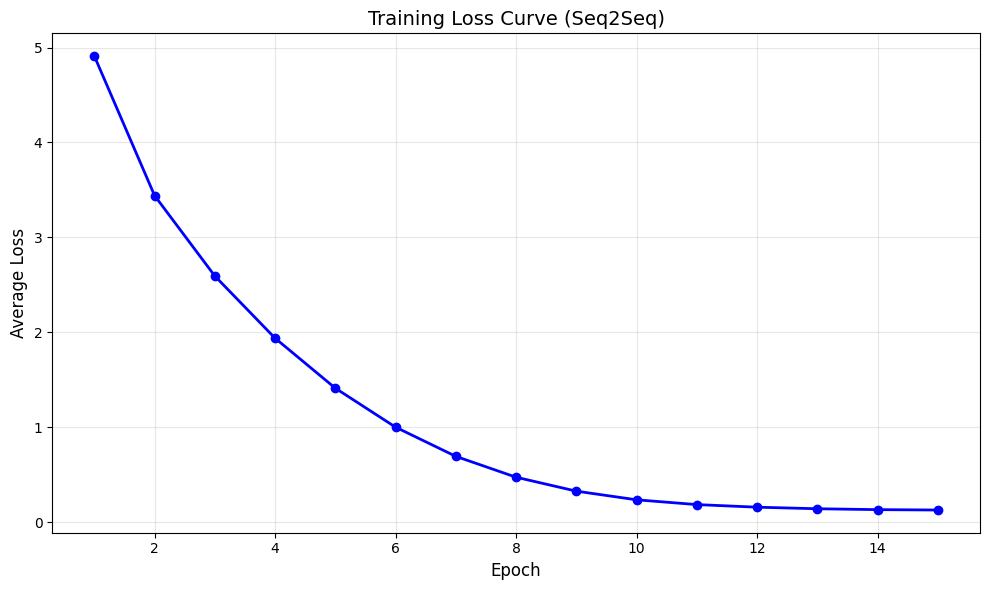


模型已保存到: ./training_checkpoints/seq2seq.pt

 Part 2.3 训练完成！


In [ ]:
# @title
# ============================================================
# 训练执行 + 可视化 + 保存 checkpoint（直接运行，无需 AI）
# ============================================================

# 执行训练（调用上面 AI 实现的 train_model 函数）
epoch_losses = train_model(
    model=model,
    train_loader=train_loader,
    num_epochs=CONFIG['num_epochs'],
    learning_rate=CONFIG['learning_rate'],
    tgt_vocab_size=len(tgt_vocab),
    pad_idx=Vocab.PAD
)

# 绘制训练 loss 曲线（英文标注，避免中文乱码）
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Training Loss Curve (Seq2Seq)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 保存模型 checkpoint
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
torch.save(model.state_dict(), CONFIG['checkpoint_path'])
print(f"\n模型已保存到: {CONFIG['checkpoint_path']}")

print("\n Part 2.3 训练完成！")

## Part 2.4: 翻译推理与 BLEU 评估

### Part 2.4 学习导航：让模型真正"翻译一句话"

**这一部分在做什么？**
使用训练好的模型，输入中文句子让模型逐词生成英文翻译，并用 BLEU 分数来量化翻译质量。

**本部分代码已完全提供，无需 AI 生成。** 直接运行即可。

**📖 概念解释**
- **推理（inference）**：用已训练好的模型对新输入做预测，不再更新参数。
- **贪心解码（Greedy Decode）**：每步选概率最高的那个词作为输出并作为下一步的输入。简单高效，但不会考虑全局最优。
- **BLEU 分数**：机器翻译常用的自动评估指标（0~1），比较"模型翻译"与"参考答案"在词或 n-gram 上的重合程度，越高越好。

> 这一步的目标不是"翻译得完美"，而是跑通"输入中文 → 模型翻译 → 输出英文 → BLEU 评分"完整闭环。

In [ ]:
# ============================================================
# 翻译推理 + BLEU 评估（直接运行，无需 AI）
# ============================================================

def translate_sentence(sentence, model, src_vocab, tgt_vocab, max_len=50, device='cuda'):
    """
    将一句中文翻译为英文（贪心解码）。

    参数:
        sentence: 中文句子 (str)
        model: 训练好的 Seq2Seq 模型
        src_vocab: 中文词表
        tgt_vocab: 英文词表
        max_len: 最大解码长度
        device: 计算设备

    返回:
        翻译结果 (str)
    """
    model.eval()

    # 中文分词 + 编码为索引序列
    tokens = jieba.lcut(sentence)
    src_indices = src_vocab.encode(tokens)
    src_tensor = torch.LongTensor([src_indices]).to(device)

    with torch.no_grad():
        # 编码器: 将中文序列压缩为隐藏状态
        _, hidden = model.encoder(src_tensor)

        # 解码器: 从 SOS 开始，逐步贪心生成英文
        input_token = torch.LongTensor([Vocab.SOS]).to(device)  # batch=1
        result_indices = []

        for _ in range(max_len):
            # 单步解码: 当前 token + 隐藏状态 -> 预测分布 + 更新隐藏状态
            output, hidden = model.decoder(input_token, hidden)
            predicted = output.argmax(dim=-1)  # 贪心: 取概率最大的词

            if predicted.item() == Vocab.EOS:  # 遇到句尾标记则停止
                break

            result_indices.append(predicted.item())
            input_token = predicted  # 将预测结果作为下一步输入

    # 将索引序列转回英文词并拼接
    result_tokens = tgt_vocab.decode(result_indices)
    return ' '.join(result_tokens)


# ---- 从验证集随机抽取 10 句进行翻译评估 ----
smoother = SmoothingFunction().method1

# 获取验证集对应的原始句对
val_start = int(len(pairs) * CONFIG['train_ratio'])
val_pairs = pairs[val_start:]
sample_pairs = random.sample(val_pairs, min(10, len(val_pairs)))

total_bleu = 0.0

print(f"{'=' * 90}")
print(f"{'Chinese (Source)':<25s} | {'English (Reference)':<25s} | {'Model Translation':<25s} | BLEU")
print(f"{'=' * 90}")

for zh, en in sample_pairs:
    # 翻译
    translation = translate_sentence(
        zh, model, src_vocab, tgt_vocab,
        max_len=CONFIG['max_len'], device=device
    )
    # 计算 BLEU（参考答案需要分词）
    ref_tokens = en.lower().split()
    hyp_tokens = translation.split()
    bleu = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoother)
    total_bleu += bleu

    # 截断显示，避免输出过长
    zh_d = zh[:23] + '..' if len(zh) > 23 else zh
    en_d = en[:23] + '..' if len(en) > 23 else en
    tr_d = translation[:23] + '..' if len(translation) > 23 else translation
    print(f"{zh_d:<25s} | {en_d:<25s} | {tr_d:<25s} | {bleu:.4f}")

avg_bleu = total_bleu / len(sample_pairs)
print(f"{'=' * 90}")
print(f"\n平均 BLEU 分数: {avg_bleu:.4f}")

print("\n Part 2.4 翻译评估完成！")

Chinese (Source)          | English (Reference)       | Model Translation         | BLEU
瑪麗昨晚熬夜。                   | Mary stayed up late las.. | mary stayed up late las.. | 1.0000
他告訴了我一個有趣的故事。             | He told me an interesti.. | he told me an interesti.. | 1.0000
這是兩件裡便宜的那個。               | This is the cheaper of .. | this is the cheaper of .. | 1.0000
我的父親死於肺癌。                 | My father died of lung .. | my father died of lung .. | 1.0000
玛丽在研究上成功了。                | Mary succeeded in her s.. | mary succeeded in her s.. | 1.0000
我聽說你擅長烹飪。                 | I hear you are good at .. | i hear you are good at .. | 1.0000
我的金絲雀被一隻貓殺死了。             | My canary was killed by.. | my canary was killed by.. | 1.0000
我明天把它带给你。                 | I'll bring it to you to.. | i'll bring it to you to.. | 1.0000
出去的时候把门关上。                | Close the door on your .. | shut the door on your w.. | 0.8091
汤姆想告诉你一些事情。               | Tom wants to tell you s.. | tom wants to tell you s.. | 1.0000



## 附加挑战（可选）: 探索翻译质量提升方法

### 附加挑战学习导航

**从以下方向中选 1~2 个进行实验：**
- **引入 Attention 机制** (Bahdanau / Luong) — 让解码器在生成每个词时"回头看"编码器所有输出
- **更换 RNN 类型** (GRU → LSTM / 双向 GRU)
- **Beam Search** 代替贪心解码
- **增加数据量** (20000 → 50000)
- **调整超参数** (hidden_dim, embedding_dim, num_layers, lr)

**📖 关键概念：**
- **Attention**：在基础 Seq2Seq 里，解码器只看编码器最后一个时间步的向量，长句信息容易丢失。Attention 让解码器在生成每个词时，根据当前需要去"看"编码器所有时间步的输出，动态分配注意力权重。
- **Beam Search**：保留概率最高的 k 个候选序列（k 叫 beam size），通常比贪心解码质量更好，但计算更贵。

**实验要求：**
1. 实现改进方案
2. 训练改进后的模型
3. 在相同验证句子上对比 BLEU
4. 输出对比结论

> 这是开放题，不要求"做到最好"，而是要有实验对比和结论。

**时间建议：** 10~15 分钟（附加题，不强制）。

### 📋 复制给 AI 的提示词（附加挑战）

```
我在做 RNN 中英翻译作业的附加挑战。运行环境中已有以下变量（不要重新定义或加载）:
- src_vocab, tgt_vocab: Vocab 实例（有 word2idx, encode, decode 方法，Vocab.PAD=0, Vocab.SOS=1, Vocab.EOS=2, Vocab.UNK=3）
- train_loader, val_loader: DataLoader
- pairs: 原始句对列表 [(中文, 英文), ...]
- device: 计算设备
- CONFIG: 超参数字典

请帮我实现 Bahdanau Attention 机制的改进模型:
1) 定义 AttentionDecoder 和 Seq2SeqWithAttention
2) 使用 train_loader 训练 (embedding_dim=256, hidden_dim=512, 15 个 epoch)
3) 实现适配 Attention 模型的翻译函数
4) 在验证集上随机抽 10 句翻译，并与基础模型对比 BLEU 分数
5) 输出 loss 曲线和 BLEU 对比表

强约束:
- 只用 torch, numpy, matplotlib, jieba, nltk
- 复用已有变量，不重新加载数据
- super().__init__() 不传额外参数
- 图表标题/坐标轴/图例必须用英文

请只输出可直接运行的纯 Python 代码。
```

**👨‍💻 将上方提示词复制到下方 AI prompt cell，生成后将代码粘贴到代码区域。**

In [ ]:
# @title 附加挑战 AI 提示词输入组件
create_ai_prompt_widget()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
import jieba
from nltk.translate.bleu_score import corpus_bleu
from nltk.tokenize import RegexpTokenizer # For English tokenization

# --- Assume these variables are pre-defined in the environment ---
# src_vocab, tgt_vocab: Vocab instances (with PAD=0, SOS=1, EOS=2, UNK=3 methods word2idx, encode, decode)
# train_loader, val_loader: DataLoader instances
# pairs: list of (Chinese_sentence, English_sentence) tuples
# device: 'cuda' or 'cpu'
# CONFIG: dictionary of hyperparameters

# Example dummy Vocab/DataLoader/CONFIG for local testing,
# these will be replaced by actuals in the target runtime environment.
try:
    # Check if variables are truly defined in the global scope
    _ = src_vocab, tgt_vocab, train_loader, val_loader, pairs, device, CONFIG
except NameError:
    print("WARNING: Dummy variables created for local testing. In the actual environment, these are pre-defined.")

    # Define a minimal Vocab class for dummy data
    class Vocab:
        PAD, SOS, EOS, UNK = 0, 1, 2, 3
        def __init__(self, name):
            self.name = name
            self.word2idx = {'<pad>': self.PAD, '<sos>': self.SOS, '<eos>': self.EOS, '<unk>': self.UNK}
            self.idx2word = {self.PAD: '<pad>', self.SOS: '<sos>', self.EOS: '<eos>', self.UNK: '<unk>'}
            self.n_words = 4 # Count SOS, EOS, PAD, UNK

        def add_sentence(self, sentence, tokenizer=None):
            if tokenizer:
                words = tokenizer(sentence)
            else:
                words = list(jieba.lcut(sentence)) # Default to jieba for Chinese
            for word in words:
                self.add_word(word)

        def add_word(self, word):
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

        def encode(self, words):
            return [self.SOS] + [self.word2idx.get(word, self.UNK) for word in words] + [self.EOS]

        def decode(self, indexes):
            # Decode, removing SOS/EOS for clean output, handle potential <pad>
            decoded_tokens = [self.idx2word.get(idx, '<unk>') for idx in indexes]
            if decoded_tokens and decoded_tokens[0] == '<sos>':
                decoded_tokens = decoded_tokens[1:]
            if decoded_tokens and decoded_tokens[-1] == '<eos>':
                decoded_tokens = decoded_tokens[:-1]
            return [token for token in decoded_tokens if token != '<pad>']

    # Dummy DataLoader
    class DummyDataLoader:
        def __init__(self, data_size, batch_size, src_vocab_size, tgt_vocab_size):
            self.data_size = data_size
            self.batch_size = batch_size
            self.src_vocab_size = src_vocab_size
            self.tgt_vocab_size = tgt_vocab_size
            self.src_max_len = 20
            self.tgt_max_len = 22

        def __iter__(self):
            for _ in range(self.data_size // self.batch_size):
                src_batch = torch.randint(Vocab.UNK, self.src_vocab_size, (self.src_max_len, self.batch_size))
                tgt_batch = torch.randint(Vocab.UNK, self.tgt_vocab_size, (self.tgt_max_len, self.batch_size))

                # Add SOS/EOS tokens
                tgt_batch[0,:] = Vocab.SOS
                tgt_batch[-1,:] = Vocab.EOS
                yield src_batch, tgt_batch

        def __len__(self):
            return self.data_size // self.batch_size

    # Setup dummy vocab and data
    src_vocab = Vocab('zh')
    tgt_vocab = Vocab('en')

    # Populate vocab with some dummy words
    for i in range(4, 100): src_vocab.add_word(f'zh_word_{i}')
    for i in range(4, 120): tgt_vocab.add_word(f'en_word_{i}')

    # Dummy pairs for translation testing
    eng_tokenizer_dummy = RegexpTokenizer(r'\w+')
    pairs = [
        ("你好 世界", "hello world"),
        ("我 爱 编程", "i love coding"),
        ("学习 机器 学习", "learn machine learning"),
        ("今天 天气 真 好", "today the weather is very good"),
        ("一个 苹果", "an apple"),
        ("蓝色 的 汽车", "a blue car"),
        ("请问 怎么 走", "excuse me how to go"),
        ("这个 很有趣", "this is very interesting"),
        ("明天 见", "see you tomorrow"),
        ("谢谢 你 的 帮助", "thank you for your help")
    ]
    # Add words from dummy pairs to vocab
    for zh, en in pairs:
        src_vocab.add_sentence(zh)
        tgt_vocab.add_sentence(en, tokenizer=lambda s: eng_tokenizer_dummy.tokenize(s.lower()))

    # Re-initialize DataLoaders with actual vocab sizes
    train_loader = DummyDataLoader(data_size=1000, batch_size=32, src_vocab_size=src_vocab.n_words, tgt_vocab_size=tgt_vocab.n_words)
    val_loader = DummyDataLoader(data_size=200, batch_size=32, src_vocab_size=src_vocab.n_words, tgt_vocab_size=tgt_vocab.n_words)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    CONFIG = {
        'embedding_dim': 256,
        'hidden_dim': 512,
        'n_layers_encoder': 2,
        'n_layers_decoder': 1,
        'dropout': 0.5,
        'lr': 0.001,
        'clip': 1.0,
        'epochs': 15
    }

# Ensure specific hyperparameters are available, using CONFIG if provided or default values
EMB_DIM = CONFIG.get('embedding_dim', 256)
HID_DIM = CONFIG.get('hidden_dim', 512)
ENC_LAYERS = CONFIG.get('n_layers_encoder', 2)
DEC_LAYERS = CONFIG.get('n_layers_decoder', 1) # Attention decoder is typically 1 layer
DROPOUT = CONFIG.get('dropout', 0.5)
LEARNING_RATE = CONFIG.get('lr', 0.001)
CLIP = CONFIG.get('clip', 1.0)
N_EPOCHS = CONFIG.get('epochs', 15)


# --- Encoder (Shared by both models for consistency) ---
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, dropout=dropout, bidirectional=True)
        # Linear layer to transform concatenated bidirectional hidden states to a single direction
        self.fc_hidden = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src len, batch size, emb dim]

        outputs, hidden = self.rnn(embedded)
        # outputs = [src len, batch size, hid dim * num directions] (all hidden states)
        # hidden = [num layers * num directions, batch size, hid dim] (final hidden state of each layer/direction)

        # Initialize decoder's hidden state:
        # Take the final forward and backward hidden states from the TOP layer of the encoder
        # hidden[-2, :, :] is the final forward hidden state of the top layer
        # hidden[-1, :, :] is the final backward hidden state of the top layer
        hidden = torch.tanh(self.fc_hidden(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        # hidden = [batch size, hid dim]
        # Unsqueeze to make it [1, batch size, hid dim] for the decoder's GRU (if decoder is single layer)
        hidden = hidden.unsqueeze(0) # [1, batch size, hid dim]

        return outputs, hidden

# --- 1) Define AttentionDecoder and Seq2SeqWithAttention ---
class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        # Bahdanau attention: v^T tanh(W_h h_i + W_s s_t)
        # W_h h_i: enc_hid_dim * 2 (because encoder is bidirectional)
        # W_s s_t: dec_hid_dim
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [1, batch size, dec hid dim] (current decoder hidden state)
        # encoder_outputs = [src len, batch size, enc hid dim * 2] (all encoder outputs)

        batch_size = encoder_outputs.shape[1]
        src_len = encoder_outputs.shape[0]

        # Repeat decoder hidden state src_len times to concatenate with each encoder output
        # [1, batch size, dec hid dim] -> [batch size, 1, dec hid dim] -> [batch size, src len, dec hid dim]
        hidden = hidden.squeeze(0).unsqueeze(1).repeat(1, src_len, 1)

        # Permute encoder_outputs for batch processing with `torch.cat`
        # [src len, batch size, enc hid dim * 2] -> [batch size, src len, enc hid dim * 2]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # Concatenate and apply tanh activation for the energy function
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        # energy = [batch size, src len, dec hid dim]

        # Apply v to get attention scores
        attention = self.v(energy).squeeze(2)
        # attention = [batch size, src len]

        return F.softmax(attention, dim=1) # Apply softmax to get attention weights

class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, n_layers, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # GRU for decoder. Input: concatenated context vector and embedded input.
        # Context vector dim: enc_hid_dim * 2
        # Embedded input dim: emb_dim
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim, n_layers, dropout=dropout)
        # Output layer. Input: concatenated context vector, decoder output (hidden), and embedded input.
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size] (previous predicted token or actual target token)
        # hidden = [n_layers, batch size, dec hid dim] (previous decoder hidden state, n_layers is 1 for our case)
        # encoder_outputs = [src len, batch size, enc hid dim * 2] (all encoder outputs)

        input = input.unsqueeze(0) # [1, batch size]

        embedded = self.dropout(self.embedding(input)) # [1, batch size, emb dim]

        # Calculate attention weights based on current decoder hidden state and all encoder outputs
        attn_weights = self.attention(hidden, encoder_outputs) # [batch size, src len]

        attn_weights = attn_weights.unsqueeze(1) # [batch size, 1, src len]

        encoder_outputs = encoder_outputs.permute(1, 0, 2) # [batch size, src len, enc hid dim * 2]

        # Calculate context vector: weighted sum of encoder outputs
        context = torch.bmm(attn_weights, encoder_outputs).permute(1, 0, 2)
        # context = [1, batch size, enc hid dim * 2]

        # Concatenate embedded input and context vector as input to GRU
        rnn_input = torch.cat((embedded, context), dim=2)
        # rnn_input = [1, batch size, (enc hid dim * 2) + emb dim]

        # Pass through GRU
        output, hidden = self.rnn(rnn_input, hidden)
        # output = [1, batch size, dec hid dim] (top layer output)
        # hidden = [n_layers, batch size, dec hid dim] (next hidden state)

        # For final prediction, combine output, context, and embedded input
        # Note: output is the hidden state of the top layer at this timestep
        prediction_input = torch.cat((output.squeeze(0), context.squeeze(0), embedded.squeeze(0)), dim=1)
        # prediction_input = [batch size, dec hid dim + enc hid dim * 2 + emb dim]

        prediction = self.fc_out(prediction_input)
        # prediction = [batch size, output dim]

        return prediction, hidden, attn_weights.squeeze(1) # Return attn_weights for potential visualization

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio = 0.5):
        # src = [src len, batch size]
        # trg = [trg len, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # encoder_outputs is all hidden states of the input sequence (for attention)
        # hidden is the final forward and backward hidden states, passed through a linear layer (for decoder initial hidden)
        encoder_outputs, hidden = self.encoder(src)

        # first input to the decoder is the <sos> token
        input = trg[0,:]

        for t in range(1, trg_len):
            # Pass input token embedding, previous hidden state, and all encoder outputs to decoder
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)

            # Store prediction for current time step
            outputs[t] = output

            # Decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            # Get the highest predicted token from our predictions
            top1 = output.argmax(1)

            # If teacher forcing, use actual next token as next input
            # If not, use predicted token
            input = trg[t] if teacher_force else top1

        return outputs


# --- Baseline Seq2Seq model (for comparison) ---
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden):
        # input = [batch size]
        # hidden = [n layers, batch size, hid dim]

        input = input.unsqueeze(0) # [1, batch size]

        embedded = self.dropout(self.embedding(input)) # [1, batch size, emb dim]

        output, hidden = self.rnn(embedded, hidden)
        # output = [1, batch size, hid dim]
        # hidden = [n layers, batch size, hid dim]

        prediction = self.fc_out(output.squeeze(0)) # [batch size, output dim]

        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        # Assertion to ensure compatibility between encoder and decoder hidden dimensions
        assert encoder.rnn.bidirectional is True, "Encoder must be bidirectional for this setup!"
        assert encoder.fc_hidden.out_features == decoder.rnn.hidden_size, \
            "Encoder's transformed hidden state dimension must match decoder's hidden state dimension."

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src len, batch size]
        # trg = [trg len, batch size]

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # encoder_outputs are not used in this baseline Seq2Seq
        _, hidden = self.encoder(src) # get final hidden state from encoder

        input = trg[0,:] # first input to the decoder is the <sos> token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden) # pass input and previous hidden state

            outputs[t] = output # store prediction

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1

        return outputs

# --- Training and Evaluation Functions ---
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(iterator):
        src = batch[0].to(device)
        trg = batch[1].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        # trg = [trg len, batch size]
        # output = [trg len, batch size, output dim]

        output_dim = output.shape[-1]
        # Ignore <sos> token for loss calculation by slicing from 1
        output = output[1:].view(-1, output_dim)
        trg = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src = batch[0].to(device)
            trg = batch[1].to(device)

            output = model(src, trg, 0) # Turn off teacher forcing for evaluation

            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

# --- 3) Implement translation function for Attention model (and adapt for baseline) ---
# NLTK's RegexpTokenizer for consistent English tokenization in BLEU calculation
eng_tokenizer = RegexpTokenizer(r'\w+')

def translate_sentence(sentence, src_vocab, tgt_vocab, model, device, max_len=50, is_attention_model=True):
    model.eval()
    with torch.no_grad():
        # Tokenize Chinese sentence using jieba
        tokens = [token.lower() for token in jieba.lcut(sentence) if token.strip()] # Remove empty strings

        src_indexes = src_vocab.encode(tokens)
        src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device) # [src len, 1]

        encoder_outputs, hidden = model.encoder(src_tensor)

        # Initial input token to the decoder is <sos>
        input_token = torch.LongTensor([tgt_vocab.SOS]).to(device)
        trg_indexes = []

        for _ in range(max_len):
            if is_attention_model:
                output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)
            else:
                output, hidden = model.decoder(input_token, hidden)

            pred_token_idx = output.argmax(1).item()
            trg_indexes.append(pred_token_idx)

            if pred_token_idx == tgt_vocab.EOS:
                break

            input_token = torch.LongTensor([pred_token_idx]).to(device) # Next input is the predicted token

    # Decode numerical sequence back to words
    # The decode method in the dummy Vocab already handles removing SOS/EOS.
    translated_tokens = tgt_vocab.decode(trg_indexes)

    return translated_tokens # Return as list of tokens for BLEU score calculation


# --- Model Initialization ---
# Attention Model
INPUT_DIM_ATTN = src_vocab.n_words
OUTPUT_DIM_ATTN = tgt_vocab.n_words

attn = Attention(HID_DIM, HID_DIM)
attn_encoder = Encoder(INPUT_DIM_ATTN, EMB_DIM, HID_DIM, ENC_LAYERS, DROPOUT)
attn_decoder = AttentionDecoder(OUTPUT_DIM_ATTN, EMB_DIM, HID_DIM, HID_DIM, DEC_LAYERS, DROPOUT, attn)
attn_model = Seq2SeqWithAttention(attn_encoder, attn_decoder, device).to(device)

attn_optimizer = optim.Adam(attn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=src_vocab.PAD) # Ignore padding token in loss

# Baseline Model
INPUT_DIM_BASE = src_vocab.n_words
OUTPUT_DIM_BASE = tgt_vocab.n_words

base_encoder = Encoder(INPUT_DIM_BASE, EMB_DIM, HID_DIM, ENC_LAYERS, DROPOUT)
base_decoder = Decoder(OUTPUT_DIM_BASE, EMB_DIM, HID_DIM, DEC_LAYERS, DROPOUT)
base_model = Seq2Seq(base_encoder, base_decoder, device).to(device)

base_optimizer = optim.Adam(base_model.parameters(), lr=LEARNING_RATE)


# --- 2) Train models (with 15 epochs) ---
print(f"Training Attention Model on {device}...")
attn_train_losses = []
attn_val_losses = []

for epoch in range(N_EPOCHS):
    attn_train_loss = train(attn_model, train_loader, attn_optimizer, criterion, CLIP)
    attn_val_loss = evaluate(attn_model, val_loader, criterion)

    attn_train_losses.append(attn_train_loss)
    attn_val_losses.append(attn_val_loss)

    print(f'Attention Model | Epoch: {epoch+1:02} | Train Loss: {attn_train_loss:.3f} | Validation Loss: {attn_val_loss:.3f}')

print(f"\nTraining Baseline Model on {device}...")
base_train_losses = []
base_val_losses = []

for epoch in range(N_EPOCHS):
    base_train_loss = train(base_model, train_loader, base_optimizer, criterion, CLIP)
    base_val_loss = evaluate(base_model, val_loader, criterion)

    base_train_losses.append(base_train_loss)
    base_val_losses.append(base_val_loss)

    print(f'Baseline Model | Epoch: {epoch+1:02} | Train Loss: {base_train_loss:.3f} | Validation Loss: {base_val_loss:.3f}')

# --- 5) Output loss curve ---
plt.figure(figsize=(12, 6))
plt.plot(attn_train_losses, label='Attention Model Training Loss')
plt.plot(attn_val_losses, label='Attention Model Validation Loss')
plt.plot(base_train_losses, label='Baseline Model Training Loss')
plt.plot(base_val_losses, label='Baseline Model Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- 4) Randomly sample 10 sentences for translation and BLEU score comparison ---
print("\n--- Translation Samples and BLEU Score Comparison ---")

# Get 10 random sentences from the actual 'pairs' list
random_indices = random.sample(range(len(pairs)), min(10, len(pairs)))
sample_pairs = [pairs[i] for i in random_indices]

attention_candidates = []
baseline_candidates = []
references = [] # List of lists of tokenized reference sentences

print(f"{'Source (Chinese)':<25} | {'Reference (English)':<25} | {'Attention Model Prediction':<30} | {'Baseline Model Prediction':<30}")
print("-" * 120)

for zh_sentence, en_sentence in sample_pairs:
    # Reference for BLEU: list of tokenized words
    ref_tokens = eng_tokenizer.tokenize(en_sentence.lower())
    references.append([ref_tokens]) # corpus_bleu expects a list of lists of tokens

    # Attention Model translation
    attn_translation_tokens = translate_sentence(zh_sentence, src_vocab, tgt_vocab, attn_model, device, is_attention_model=True)
    attention_candidates.append(attn_translation_tokens)

    # Baseline Model translation
    base_translation_tokens

## 📖 Task 2 知识延伸：从 Seq2Seq 到大语言模型

Task 2 做完了。你搭的 Encoder-Decoder 翻译模型效果可能不太理想——但它恰好是通往 Transformer 和 ChatGPT 的起点。下面简单梳理这条技术路线。

---

### 为什么翻译效果不理想？

你大概已经发现：训练 loss 降得很低，但实际翻译时质量不怎么样。问题不在代码，而在架构本身有三个天花板：

| 问题 | 原因 | 类比 |
|---|---|---|
| **信息瓶颈** | 整个中文句子被挤进一个固定长度的向量（如 512 维），信息大量丢失 | 让你用一句话概括一整篇文章，再只靠这句话把原文翻译出来 |
| **顺序处理** | GRU 必须一个词一个词地读，无法并行，也容易"忘记"前面的内容 | 一个字一个字听完一段话，听到最后已经忘了开头说什么 |
| **长距离依赖** | 句子越长，开头的信息经过多步传递后衰减越严重 | 传话游戏——经过十个人转述，原话面目全非 |

> 所以你会发现：短句（"谢谢" → "thanks"）翻得还行，长句基本不能看。

### 第一个突破：Attention（2014-2015）

Attention 的想法很直接：解码器在生成每个英文词时，不再只看那个压缩向量，而是回头看编码器处理过的每一个中文词，动态决定「这一步重点关注哪些词」。

```
普通 Seq2Seq:  中文 ──→ [一个向量] ──→ 英文
带 Attention:  中文 ──→ [所有中间状态] ←── 解码器每步回头看最相关的部分 ──→ 英文
```

效果能提升多少？
- 在 20k 数据的任务上，加 Attention 通常能让 BLEU 从 ~15 提升到 ~25；
- 在大规模数据上，Attention 让机器翻译第一次接近了人类水平。

> 附加挑战里有 Attention 的实验，做了的话应该已经体会到差距。

### 第二个突破：Transformer（2017）

2017 年 Google 提出了一个激进的想法：既然 Attention 这么好用，为什么还需要 RNN？干脆全用 Attention。

这就是 Transformer 的由来。它和你的 Seq2Seq 有三个关键区别：

| 对比项 | Seq2Seq (GRU) | Transformer |
|---|---|---|
| 信息传递 | 逐词顺序传递 | 所有词同时互相"对话"（Self-Attention） |
| 并行能力 | 无法并行 | 完全并行，训练速度快几十倍 |
| 长距离依赖 | 靠记忆链传递，容易遗忘 | 任意两个词直接建立连接，没有距离衰减 |

Self-Attention 的直觉：在 GRU 里，"我"要经过 5 步传递才能影响到句末的"了"；在 Transformer 里，"我"和"了"直接算一个注意力权重，一步到位。

### 第三个突破：大语言模型（2018 至今）

Transformer 提出后，OpenAI 做了一件看起来很简单的事：把解码器叠得非常深、喂非常多的文本，训练目标只有一个——预测下一个词。

| 模型 | 年份 | 参数量 | 训练数据 |
|---|---|---|---|
| GPT-1 | 2018 | 1.17 亿 | ~5GB 文本 |
| GPT-2 | 2019 | 15 亿 | ~40GB 文本 |
| GPT-3 | 2020 | 1750 亿 | ~570GB 文本 |
| GPT-4 | 2023 | 未公开（估计万亿级） | 未公开 |

背后的核心发现是 Scaling Law（缩放定律）：
> 模型参数量、数据量、算力三者同步增大时，模型能力持续且可预测地提升。

不需要发明全新的算法，把 Transformer 做大、喂更多数据、用更多 GPU，效果就会持续提升。这也是为什么如今 AI 领域的竞争，很大程度上变成了算力和数据的竞争。

### 你的实验在这条路上的位置

```
Seq2Seq (GRU)               ← 2014 年水平
    ↓ + Attention           ← 2015 年水平（附加挑战）
    ↓ 去掉 RNN，改用纯 Attention
Transformer                 ← 2017 年水平
    ↓ 堆更多层 + 更多数据
GPT / BERT                  ← 2018-2019 年水平
    ↓ 继续缩放
ChatGPT / GPT-4             ← 2022-2023 年水平
```

你今天用 GRU 做翻译遇到的问题，就是十年前研究者面对的真实困境。正是为了解决这些问题，Attention 和 Transformer 才被相继提出。理解了「为什么不行」，才能真正理解后来的方案为什么行。

> 从 GRU Seq2Seq 到 ChatGPT，核心跳跃只有两步：加 Attention，去掉 RNN 换 Transformer。剩下的，就是不断把它做大。